In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("../depression_data_11Col/Depression Student Dataset.csv")
encode = LabelEncoder()
df_categorical = df.select_dtypes(include=['object', 'category']).columns.tolist()
for column in df_categorical: 
    df[column] = encode.fit_transform(df[column])

from sklearn.model_selection import train_test_split

x = df.drop(columns=["Depression"])
y =df["Depression"]

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42, stratify=y)

/var/folders/81/5jvybkl57zd09pzmbs44y4500000gn/T/ipykernel_71566/1271765073.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_categorical = df.select_dtypes(include=['object', 'category']).columns.tolist()


In [ ]:
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import (accuracy_score, f1_score, cohen_kappa_score,
                             recall_score, precision_score, roc_auc_score,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Split into 60% train / 20% val / 20% test
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.25, random_state=42, stratify=y_train)

# tree-based, no scaling needed
bagging = BaggingClassifier(n_estimators=100)
bagging.fit(x_train, y_train)

,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeClassifier`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",100
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",None
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary `... versionadded:: 0.17 *warm_start* constructor parameter.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


Train Accuracy : 1.0000
Val Accuracy   : 0.8317
Test Accuracy  : 0.9010
F1 Score       : 0.9107
Kappa          : 0.8003
Recall         : 0.9623
Precision      : 0.8644
AUC            : 0.9691


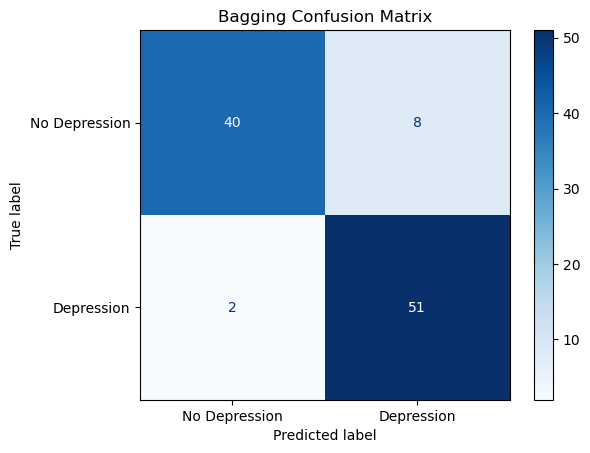

In [6]:
y_train_pred = bagging.predict(x_train)
y_val_pred   = bagging.predict(x_val)
y_test_pred  = bagging.predict(x_test)
y_test_proba = bagging.predict_proba(x_test)[:, 1]

print(f"Train Accuracy : {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Val Accuracy   : {accuracy_score(y_val, y_val_pred):.4f}")
print(f"Test Accuracy  : {accuracy_score(y_test, y_test_pred):.4f}")
print(f"F1 Score       : {f1_score(y_test, y_test_pred):.4f}")
print(f"Kappa          : {cohen_kappa_score(y_test, y_test_pred):.4f}")
print(f"Recall         : {recall_score(y_test, y_test_pred):.4f}")
print(f"Precision      : {precision_score(y_test, y_test_pred):.4f}")
print(f"AUC            : {roc_auc_score(y_test, y_test_proba):.4f}")

display = ConfusionMatrixDisplay(confusion_matrix(y_test, y_test_pred), display_labels=["No Depression", "Depression"])
display.plot(cmap="Blues")
plt.title("Bagging Confusion Matrix")
plt.show()